<a href="https://colab.research.google.com/github/Ehtehsham/FishCNN/blob/main/FishCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/fish_dataset
!rm -rf /content/fish_12classes

In [ ]:
import os
import shutil
import random

# =========================================================
# MAIN GOOGLE DRIVE DATASET FOLDER
# =========================================================

ROOT = "/content/drive/MyDrive/MatsyaDx-BD An image dataset of freshwater fish di"

# =========================================================
# AUTOMATICALLY FIND THE REAL DATASET ROOT
# =========================================================

required_disease_folders = {
    "Healthy Fish",
    "Bacterial Gill Diseases",
    "Bacterial Red Diseases",
    "Epizootic Ulcerative Syndrome (EUS)"
}

dataset_root = None

for current_root, dirs, files in os.walk(ROOT):

    # Check whether this folder contains the disease folders
    if required_disease_folders.issubset(set(dirs)):
        dataset_root = current_root
        break

if dataset_root is None:
    raise FileNotFoundError(
        "Could not find MatsyaDx-BD dataset root. "
        "Please check that the dataset exists in Google Drive."
    )

print("Dataset root found:")
print(dataset_root)

# =========================================================
# OUTPUT FOLDERS
# =========================================================

FLAT_DIR = "/content/fish_12classes"
OUTPUT_DIR = "/content/fish_dataset"

# Remove old folders
if os.path.exists(FLAT_DIR):
    shutil.rmtree(FLAT_DIR)

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(FLAT_DIR)
os.makedirs(OUTPUT_DIR)

# =========================================================
# DISEASE NAMES
# =========================================================

disease_map = {
    "Healthy Fish": "Healthy",
    "Bacterial Gill Diseases": "Gill",
    "Bacterial Red Diseases": "Red",
    "Epizootic Ulcerative Syndrome (EUS)": "EUS"
}

# =========================================================
# FISH SPECIES NAMES
# =========================================================

species_map = {
    "Grass_carp_(Ctenopharyngodon idella)": "GrassCarp",
    "Rui_(Labeo rohita)": "Rui",
    "Silver_carp_(Hypophthalmichthys molitrix)": "SilverCarp"
}

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

# =========================================================
# CREATE THE 12 CLASSES
# =========================================================

print("\nCreating 12-class dataset...\n")

for disease_folder, disease_short in disease_map.items():

    disease_path = os.path.join(
        dataset_root,
        disease_folder
    )

    print("Processing:", disease_folder)

    # Find species folders anywhere inside the disease folder
    for current_root, dirs, files in os.walk(disease_path):

        folder_name = os.path.basename(current_root)

        if folder_name not in species_map:
            continue

        species_short = species_map[folder_name]

        class_name = (
            disease_short
            + "_"
            + species_short
        )

        destination = os.path.join(
            FLAT_DIR,
            class_name
        )

        os.makedirs(
            destination,
            exist_ok=True
        )

        # Current number already copied
        image_number = len([
            f for f in os.listdir(destination)
            if f.lower().endswith(IMAGE_EXTENSIONS)
        ])

        # =================================================
        # RECURSIVELY FIND IMAGES
        # Handles:
        #
        # Species/
        #    Fish_1/
        #       images
        #
        # Species/
        #    Fish_2/
        #       images
        # =================================================

        for image_root, image_dirs, image_files in os.walk(
            current_root
        ):

            for file in image_files:

                if file.lower().endswith(
                    IMAGE_EXTENSIONS
                ):

                    source_file = os.path.join(
                        image_root,
                        file
                    )

                    extension = os.path.splitext(
                        file
                    )[1].lower()

                    # Give every file a unique name
                    new_name = (
                        f"{class_name}_"
                        f"{image_number:05d}"
                        f"{extension}"
                    )

                    destination_file = os.path.join(
                        destination,
                        new_name
                    )

                    shutil.copy2(
                        source_file,
                        destination_file
                    )

                    image_number += 1

        print(
            f"   {class_name}: "
            f"{image_number} images"
        )

        # Stop os.walk entering this species folder again
        dirs[:] = []


# =========================================================
# CHECK THE CREATED 12 CLASSES
# =========================================================

print("\n")
print("=" * 60)
print("12 CLASS DATASET")
print("=" * 60)

total_images = 0

class_counts = {}

for class_name in sorted(
    os.listdir(FLAT_DIR)
):

    class_path = os.path.join(
        FLAT_DIR,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    count = len([
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ])

    class_counts[class_name] = count

    total_images += count

    print(
        f"{class_name:<25} "
        f"{count:>4} images"
    )

print("=" * 60)
print("Number of classes:", len(class_counts))
print("Total images:", total_images)
print("=" * 60)


# =========================================================
# SAFETY CHECK
# =========================================================

if len(class_counts) != 12:

    print("\nWARNING!")
    print(
        "Expected 12 classes but found:",
        len(class_counts)
    )

if total_images == 0:

    raise ValueError(
        "No images were found."
    )


# =========================================================
# CREATE TRAIN / VALIDATION / TEST
#
# 80% Train
# 10% Validation
# 10% Test
# =========================================================

random.seed(42)

for split in [
    "train",
    "val",
    "test"
]:

    split_folder = os.path.join(
        OUTPUT_DIR,
        split
    )

    os.makedirs(
        split_folder,
        exist_ok=True
    )


print("\nSplitting dataset...\n")


for class_name in sorted(
    os.listdir(FLAT_DIR)
):

    class_path = os.path.join(
        FLAT_DIR,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    images = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]

    random.shuffle(images)

    total = len(images)

    train_count = int(
        total * 0.80
    )

    val_count = int(
        total * 0.10
    )

    train_images = images[
        :train_count
    ]

    val_images = images[
        train_count:
        train_count + val_count
    ]

    test_images = images[
        train_count + val_count:
    ]

    # =====================================================
    # COPY TRAIN
    # =====================================================

    train_destination = os.path.join(
        OUTPUT_DIR,
        "train",
        class_name
    )

    os.makedirs(
        train_destination,
        exist_ok=True
    )

    for image_name in train_images:

        shutil.copy2(
            os.path.join(
                class_path,
                image_name
            ),
            os.path.join(
                train_destination,
                image_name
            )
        )

    # =====================================================
    # COPY VALIDATION
    # =====================================================

    val_destination = os.path.join(
        OUTPUT_DIR,
        "val",
        class_name
    )

    os.makedirs(
        val_destination,
        exist_ok=True
    )

    for image_name in val_images:

        shutil.copy2(
            os.path.join(
                class_path,
                image_name
            ),
            os.path.join(
                val_destination,
                image_name
            )
        )

    # =====================================================
    # COPY TEST
    # =====================================================

    test_destination = os.path.join(
        OUTPUT_DIR,
        "test",
        class_name
    )

    os.makedirs(
        test_destination,
        exist_ok=True
    )

    for image_name in test_images:

        shutil.copy2(
            os.path.join(
                class_path,
                image_name
            ),
            os.path.join(
                test_destination,
                image_name
            )
        )

    print(
        f"{class_name:<25} "
        f"Train={len(train_images):3d}  "
        f"Val={len(val_images):3d}  "
        f"Test={len(test_images):3d}"
    )


# =========================================================
# FINAL COUNTS
# =========================================================

train_total = 0
val_total = 0
test_total = 0

for class_name in os.listdir(
    FLAT_DIR
):

    train_class = os.path.join(
        OUTPUT_DIR,
        "train",
        class_name
    )

    val_class = os.path.join(
        OUTPUT_DIR,
        "val",
        class_name
    )

    test_class = os.path.join(
        OUTPUT_DIR,
        "test",
        class_name
    )

    if os.path.exists(train_class):
        train_total += len(
            os.listdir(train_class)
        )

    if os.path.exists(val_class):
        val_total += len(
            os.listdir(val_class)
        )

    if os.path.exists(test_class):
        test_total += len(
            os.listdir(test_class)
        )


print("\n")
print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print(
    "Training images   :",
    train_total
)

print(
    "Validation images :",
    val_total
)

print(
    "Testing images    :",
    test_total
)

print(
    "Total             :",
    train_total
    + val_total
    + test_total
)

print("=" * 60)

print(
    "\nDataset preparation completed successfully!"
)

Dataset root found:
/content/drive/MyDrive/MatsyaDx-BD An image dataset of freshwater fish di/MatsyaDx-BD

Creating 12-class dataset...

Processing: Healthy Fish
   Healthy_SilverCarp: 396 images
   Healthy_GrassCarp: 222 images
   Healthy_Rui: 259 images
Processing: Bacterial Gill Diseases
   Gill_Rui: 82 images
   Gill_SilverCarp: 87 images
   Gill_GrassCarp: 64 images
Processing: Bacterial Red Diseases
   Red_GrassCarp: 227 images
   Red_Rui: 189 images
   Red_SilverCarp: 160 images
Processing: Epizootic Ulcerative Syndrome (EUS)
   EUS_Rui: 212 images
   EUS_SilverCarp: 34 images
   EUS_GrassCarp: 86 images


12 CLASS DATASET
EUS_GrassCarp               86 images
EUS_Rui                    212 images
EUS_SilverCarp              34 images
Gill_GrassCarp              64 images
Gill_Rui                    82 images
Gill_SilverCarp             87 images
Healthy_GrassCarp          222 images
Healthy_Rui                259 images
Healthy_SilverCarp         396 images
Red_GrassCarp       

In [ ]:
train_dir = "/content/fish_dataset/train"
val_dir   = "/content/fish_dataset/val"
test_dir  = "/content/fish_dataset/test"

In [ ]:
print("Train exists:", os.path.exists(train_dir))
print("Valid exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Valid exists: True
Test exists: True


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [ ]:
# =========================================================
# ROUND 1 vs ROUND 2 DATASETS
# Round 1 -> baseline, NO augmentation (uses test_transform)
# Round 2 -> WITH augmentation (uses train_transform)
# =========================================================

train_dataset_basic = datasets.ImageFolder(
    root=train_dir,
    transform=test_transform      # no augmentation -> baseline
)

train_dataset_aug = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform     # augmentation -> Round 2
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

In [ ]:
# =========================================================
# CALCULATE CLASS COUNTS (same for both rounds - same images)
# =========================================================

train_targets = np.array(train_dataset_aug.targets)

class_counts = np.bincount(
    train_targets,
    minlength=len(train_dataset_aug.classes)
)

print("Training class distribution:")
for i, class_name in enumerate(train_dataset_aug.classes):
    print(f"{class_name:<25}: {class_counts[i]}")

# =========================================================
# CALCULATE BALANCING WEIGHTS
# =========================================================

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_targets]
sample_weights = torch.DoubleTensor(sample_weights)

# =========================================================
# WEIGHTED SAMPLERS (one per round)
# =========================================================

train_sampler_basic = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_sampler_aug = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader_basic = DataLoader(
    train_dataset_basic,
    batch_size=32,
    sampler=train_sampler_basic
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=32,
    sampler=train_sampler_aug
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Training class distribution:
EUS_GrassCarp            : 68
EUS_Rui                  : 169
EUS_SilverCarp           : 27
Gill_GrassCarp           : 51
Gill_Rui                 : 65
Gill_SilverCarp          : 69
Healthy_GrassCarp        : 177
Healthy_Rui              : 207
Healthy_SilverCarp       : 316
Red_GrassCarp            : 181
Red_Rui                  : 151
Red_SilverCarp           : 128


In [ ]:
print("Classes:", train_dataset_aug.classes)
print("Number of training images:", len(train_dataset_aug))
print("Number of validation images:", len(val_dataset))
print("Number of test images:", len(test_dataset))

Classes: ['EUS_GrassCarp', 'EUS_Rui', 'EUS_SilverCarp', 'Gill_GrassCarp', 'Gill_Rui', 'Gill_SilverCarp', 'Healthy_GrassCarp', 'Healthy_Rui', 'Healthy_SilverCarp', 'Red_GrassCarp', 'Red_Rui', 'Red_SilverCarp']
Number of training images: 1609
Number of validation images: 196
Number of test images: 213


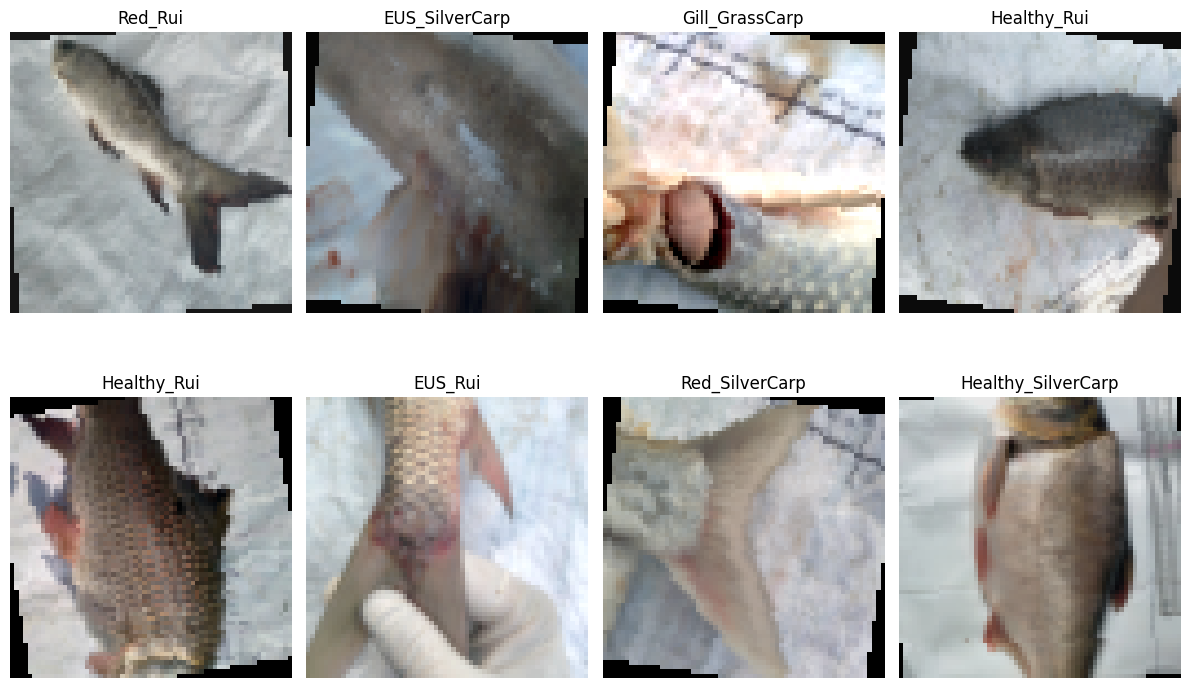

In [ ]:
def imshow_tensor(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

images, labels = next(iter(train_loader_aug))
class_names = train_dataset_aug.classes

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    imshow_tensor(images[i].cpu())
    plt.title(class_names[labels[i]])
plt.tight_layout()
plt.show()

In [ ]:
class CustomCNN(nn.Module):

    def __init__(
        self,
        num_classes=12,
        use_batchnorm=True,
        use_dropout=True
    ):
        super(CustomCNN, self).__init__()

        # ==========================================
        # Convolution Block 1
        # ==========================================

        layers = [
            nn.Conv2d(
                in_channels=3,
                out_channels=64,
                kernel_size=3,
                padding=1
            )
        ]

        if use_batchnorm:
            layers.append(
                nn.BatchNorm2d(64)
            )

        layers.extend([
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        ])

        # ==========================================
        # Convolution Block 2
        # ==========================================

        layers.append(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            )
        )

        if use_batchnorm:
            layers.append(
                nn.BatchNorm2d(128)
            )

        layers.extend([
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        ])

        # ==========================================
        # Convolution Block 3
        # ==========================================

        layers.append(
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            )
        )

        if use_batchnorm:
            layers.append(
                nn.BatchNorm2d(256)
            )

        layers.extend([
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        ])

        self.features = nn.Sequential(
            *layers
        )

        # ==========================================
        # Classifier
        # ==========================================

        classifier_layers = [
            nn.Flatten(),

            # 64x64 image
            # after 3 pooling layers:
            # 64 -> 32 -> 16 -> 8
            nn.Linear(
                256 * 8 * 8,
                512
            ),

            nn.ReLU(inplace=True)
        ]

        # Dropout to reduce overfitting
        if use_dropout:
            classifier_layers.append(
                nn.Dropout(0.5)
            )

        # 12 fish classes
        classifier_layers.append(
            nn.Linear(
                512,
                num_classes
            )
        )

        self.classifier = nn.Sequential(
            *classifier_layers
        )

    # ==============================================
    # Forward Pass
    # ==============================================

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
class_names = train_dataset_aug.classes
num_classes = len(class_names)

print("Classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("\nNumber of classes:", num_classes)
print("Device:", device)

Classes:
0: EUS_GrassCarp
1: EUS_Rui
2: EUS_SilverCarp
3: Gill_GrassCarp
4: Gill_Rui
5: Gill_SilverCarp
6: Healthy_GrassCarp
7: Healthy_Rui
8: Healthy_SilverCarp
9: Red_GrassCarp
10: Red_Rui
11: Red_SilverCarp

Number of classes: 12
Device: cpu


In [ ]:
# =========================================================
# ROUND 1 MODEL — Baseline: no BatchNorm, no Dropout
# =========================================================

model_basic = CustomCNN(
    num_classes=num_classes,
    use_batchnorm=False,
    use_dropout=False
).to(device)

print("Round 1 Model Architecture (baseline):")
print(model_basic)

Round 1 Model Architecture (baseline):
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=12, bias=True)
  )
)


In [ ]:
print("Round 1 - Training Transform (NO augmentation):")
print(test_transform)

print("\nRound 1 - Dropout Layers in CNN:")
dropout_found = False
for name, layer in model_basic.named_modules():
    if isinstance(layer, nn.Dropout):
        dropout_found = True
        print(f"{name} -> Dropout probability = {layer.p}")
if not dropout_found:
    print("No Dropout layer found (expected for baseline).")

Round 1 - Training Transform (NO augmentation):
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Round 1 - Dropout Layers in CNN:
No Dropout layer found (expected for baseline).


In [ ]:
# ==========================================
# Training Function
# ==========================================

def train_one_epoch(model, train_loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    return train_loss, train_acc


# ==========================================
# Evaluation Function
# ==========================================

def evaluate(model, data_loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

    val_loss = running_loss / total
    val_acc = correct / total

    return (
        val_loss,
        val_acc,
        all_labels,
        all_predictions
    )

In [ ]:
def fit_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    lr=0.001
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=5,
        gamma=0.5
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(
        model.state_dict()
    )

    best_val_acc = 0.0

    for epoch in range(epochs):

        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_model_wts = copy.deepcopy(
                model.state_dict()
            )

        end = time.time()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {end-start:.2f}s"
        )

    model.load_state_dict(
        best_model_wts
    )

    return model, history

In [ ]:
import time
import copy
import torch.optim as optim

In [ ]:
def plot_history(history, title=""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs_range, history["train_loss"], "o-", label="train")
    ax1.plot(epochs_range, history["val_loss"], "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs_range, history["train_acc"], "o-", label="train")
    ax2.plot(epochs_range, history["val_acc"], "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
print("="*60)
print("TRAINING ROUND 1 - Baseline (no augmentation, no dropout)")
print("="*60)

model_basic, history_basic = fit_model(
    model_basic,
    train_loader_basic,
    val_loader,
    epochs=15,
    lr=0.001
)

TRAINING ROUND 1 - Baseline (no augmentation, no dropout)
Epoch [1/15] Train Loss: 1.6313 | Train Acc: 0.4730 | Val Loss: 1.1464 | Val Acc: 0.6378 | Time: 457.91s
Epoch [2/15] Train Loss: 0.4969 | Train Acc: 0.8397 | Val Loss: 0.3746 | Val Acc: 0.8673 | Time: 433.11s
Epoch [3/15] Train Loss: 0.2008 | Train Acc: 0.9434 | Val Loss: 0.2107 | Val Acc: 0.9184 | Time: 416.71s
Epoch [4/15] Train Loss: 0.0640 | Train Acc: 0.9845 | Val Loss: 0.1411 | Val Acc: 0.9490 | Time: 410.46s
Epoch [5/15] Train Loss: 0.0389 | Train Acc: 0.9894 | Val Loss: 0.1533 | Val Acc: 0.9439 | Time: 424.37s
Epoch [6/15] Train Loss: 0.0306 | Train Acc: 0.9925 | Val Loss: 0.0509 | Val Acc: 0.9847 | Time: 419.16s
Epoch [7/15] Train Loss: 0.0043 | Train Acc: 0.9994 | Val Loss: 0.0423 | Val Acc: 0.9847 | Time: 417.01s
Epoch [8/15] Train Loss: 0.0122 | Train Acc: 0.9981 | Val Loss: 0.0765 | Val Acc: 0.9592 | Time: 413.57s
Epoch [9/15] Train Loss: 0.0027 | Train Acc: 1.0000 | Val Loss: 0.0610 | Val Acc: 0.9847 | Time: 420.1

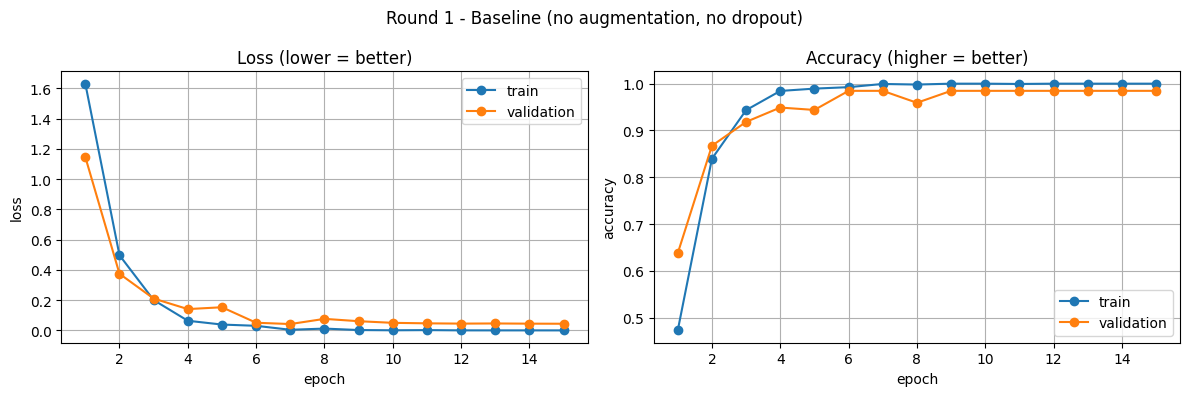

In [ ]:
plot_history(history_basic, "Round 1 - Baseline (no augmentation, no dropout)")

In [ ]:
gap_basic = max(history_basic["train_acc"]) - max(history_basic["val_acc"])
print(f"Round 1 - Best Train Acc: {max(history_basic['train_acc'])*100:.2f}%")
print(f"Round 1 - Best Val Acc:   {max(history_basic['val_acc'])*100:.2f}%")
print(f"Round 1 - Train/Val Gap:  {gap_basic*100:.2f}%  (bigger gap = more overfitting)")

Round 1 - Best Train Acc: 100.00%
Round 1 - Best Val Acc:   98.47%
Round 1 - Train/Val Gap:  1.53%  (bigger gap = more overfitting)


In [ ]:
# =========================================================
# ROUND 2 MODEL — With BatchNorm + Dropout
# =========================================================

model_aug = CustomCNN(
    num_classes=num_classes,
    use_batchnorm=True,
    use_dropout=True
).to(device)

print("Round 2 Model Architecture (augmentation + dropout):")
print(model_aug)

Round 2 Model Architecture (augmentation + dropout):
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
  

In [ ]:
print("Round 2 - Training Transform (WITH augmentation):")
print(train_transform)

print("\nRound 2 - Dropout Layers in CNN:")
dropout_found = False
for name, layer in model_aug.named_modules():
    if isinstance(layer, nn.Dropout):
        dropout_found = True
        print(f"{name} -> Dropout probability = {layer.p}")
if not dropout_found:
    print("No Dropout layer found.")

Round 2 - Training Transform (WITH augmentation):
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Round 2 - Dropout Layers in CNN:
classifier.3 -> Dropout probability = 0.5


In [ ]:
print("="*60)
print("TRAINING ROUND 2 - Augmentation + Dropout + BatchNorm")
print("="*60)

model_aug, history_aug = fit_model(
    model_aug,
    train_loader_aug,
    val_loader,
    epochs=15,
    lr=0.001
)

TRAINING ROUND 2 - Augmentation + Dropout + BatchNorm
Epoch [1/15] Train Loss: 4.2349 | Train Acc: 0.1778 | Val Loss: 1.9690 | Val Acc: 0.3520 | Time: 370.06s
Epoch [2/15] Train Loss: 2.0099 | Train Acc: 0.3089 | Val Loss: 1.8778 | Val Acc: 0.3316 | Time: 369.54s
Epoch [3/15] Train Loss: 1.7474 | Train Acc: 0.3891 | Val Loss: 1.5574 | Val Acc: 0.4643 | Time: 366.61s
Epoch [4/15] Train Loss: 1.6377 | Train Acc: 0.4220 | Val Loss: 1.2734 | Val Acc: 0.5663 | Time: 364.56s
Epoch [5/15] Train Loss: 1.4547 | Train Acc: 0.4810 | Val Loss: 0.9989 | Val Acc: 0.6837 | Time: 387.78s
Epoch [6/15] Train Loss: 1.2229 | Train Acc: 0.5656 | Val Loss: 0.9306 | Val Acc: 0.6684 | Time: 385.37s
Epoch [7/15] Train Loss: 1.0934 | Train Acc: 0.6308 | Val Loss: 0.7949 | Val Acc: 0.6990 | Time: 386.95s
Epoch [8/15] Train Loss: 1.0427 | Train Acc: 0.6271 | Val Loss: 0.8079 | Val Acc: 0.7194 | Time: 360.08s
Epoch [9/15] Train Loss: 0.9994 | Train Acc: 0.6314 | Val Loss: 0.5784 | Val Acc: 0.8163 | Time: 368.39s
E

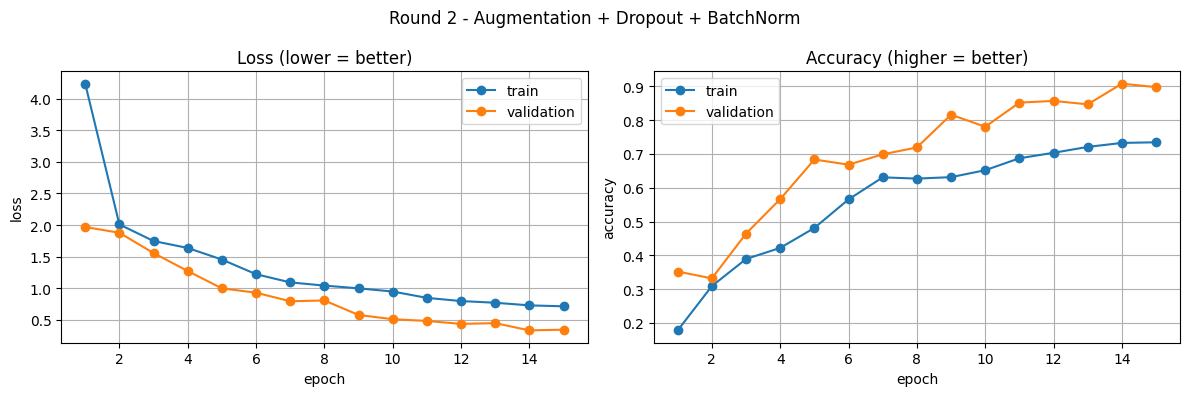

In [ ]:
plot_history(history_aug, "Round 2 - Augmentation + Dropout + BatchNorm")

In [ ]:
gap_aug = max(history_aug["train_acc"]) - max(history_aug["val_acc"])
print(f"Round 2 - Best Train Acc: {max(history_aug['train_acc'])*100:.2f}%")
print(f"Round 2 - Best Val Acc:   {max(history_aug['val_acc'])*100:.2f}%")
print(f"Round 2 - Train/Val Gap:  {gap_aug*100:.2f}%")

print("\n" + "="*60)
print("OVERFITTING COMPARISON")
print("="*60)
print(f"Round 1 (baseline)        gap: {gap_basic*100:.2f}%")
print(f"Round 2 (aug + dropout)   gap: {gap_aug*100:.2f}%")
if gap_aug < gap_basic:
    print("-> Overfitting was REDUCED by augmentation + dropout.")
else:
    print("-> Gap did not shrink - consider more epochs, stronger augmentation, or more dropout.")

Round 2 - Best Train Acc: 73.46%
Round 2 - Best Val Acc:   90.82%
Round 2 - Train/Val Gap:  -17.35%

OVERFITTING COMPARISON
Round 1 (baseline)        gap: 1.53%
Round 2 (aug + dropout)   gap: -17.35%
-> Overfitting was REDUCED by augmentation + dropout.


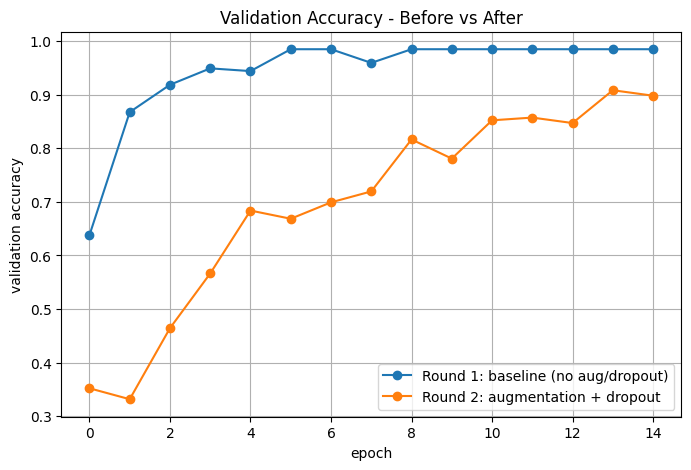

Best val acc (Round 1): 0.985
Best val acc (Round 2): 0.908


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_basic["val_acc"], "o-", label="Round 1: baseline (no aug/dropout)")
plt.plot(history_aug["val_acc"], "o-", label="Round 2: augmentation + dropout")
plt.title("Validation Accuracy - Before vs After")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best val acc (Round 1): {max(history_basic['val_acc']):.3f}")
print(f"Best val acc (Round 2): {max(history_aug['val_acc']):.3f}")

In [ ]:
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_labels, test_preds = evaluate(
    model_aug,
    test_loader,
    criterion
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 0.3725
Test Accuracy: 88.26%


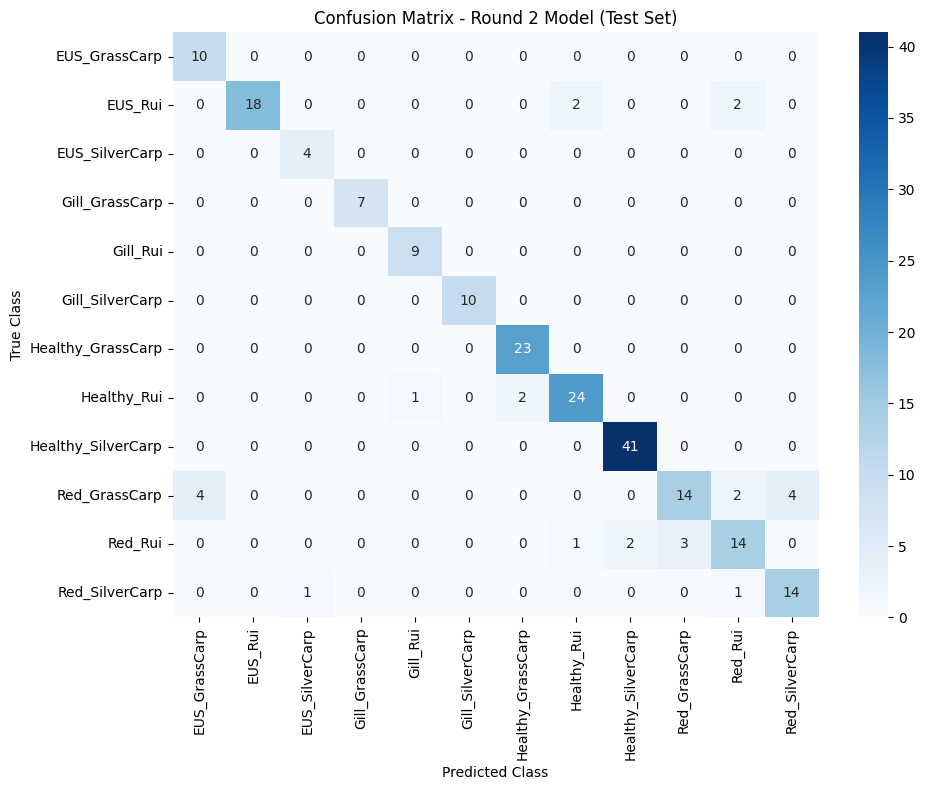

Classification Report:
                    precision    recall  f1-score   support

     EUS_GrassCarp       0.71      1.00      0.83        10
           EUS_Rui       1.00      0.82      0.90        22
    EUS_SilverCarp       0.80      1.00      0.89         4
    Gill_GrassCarp       1.00      1.00      1.00         7
          Gill_Rui       0.90      1.00      0.95         9
   Gill_SilverCarp       1.00      1.00      1.00        10
 Healthy_GrassCarp       0.92      1.00      0.96        23
       Healthy_Rui       0.89      0.89      0.89        27
Healthy_SilverCarp       0.95      1.00      0.98        41
     Red_GrassCarp       0.82      0.58      0.68        24
           Red_Rui       0.74      0.70      0.72        20
    Red_SilverCarp       0.78      0.88      0.82        16

          accuracy                           0.88       213
         macro avg       0.88      0.91      0.88       213
      weighted avg       0.89      0.88      0.88       213



In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Round 2 Model (Test Set)")
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

In [ ]:
best_epoch = np.argmax(history_aug["val_acc"])

best_train_acc = history_aug["train_acc"][best_epoch]
best_val_acc = history_aug["val_acc"][best_epoch]

best_train_loss = history_aug["train_loss"][best_epoch]
best_val_loss = history_aug["val_loss"][best_epoch]

print(f"Best Epoch: {best_epoch + 1}")
print(f"Training Accuracy: {best_train_acc * 100:.2f}%")
print(f"Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print(f"\nTraining Loss: {best_train_loss:.4f}")
print(f"Validation Loss: {best_val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Best Epoch: 14
Training Accuracy: 73.28%
Validation Accuracy: 90.82%
Test Accuracy: 88.26%

Training Loss: 0.7302
Validation Loss: 0.3347
Test Loss: 0.3725


In [ ]:
total_params = sum(p.numel() for p in model_aug.parameters() if p.requires_grad)
print("Total trainable parameters (Round 2 model):", total_params)

Total trainable parameters (Round 2 model): 8766988
